#Challenge Overview

##Analyzing retail data to create customer segments and enhance marketing campaigns based on customer behaviour in each segment

a large raw table is provided (online retail with more than 500 k rows). Each row includes a customer id, invoice number and description of sold items and purchase time. To biuld insights on how to improve marketing, we need to understand customers' behaviour by grouping them into different segments(clusters) based on their activity, e.g. frequent buyer, low spender.

This helps to target each marketing technique at the right group of customers.

##ML Technique
We use GMM (Gaussian Mixture Model) to introduce clusters (more accurately, the probability that a customer belongs to a cluster since customers' behaviour is not always fixed).

#Steps Overview


###1. Feature Creation (RFM Model):

For each customer, we calculate three key behavioural features,

Recency (R): Number of days since their last purchase.

Frequency (F): Number of purchase transactions.

Monetary (M): Total amount of money spent.

###2. Data Preparation

**Standardizing** the RFM values (so all features are on the same scale).

**Applying PCA** (Principal Component Analysis) to reduce the RFM data into 2 dimensions.

###3. Clustering with GMM

We then apply a Gaussian Mixture Model which performs soft clustering. each customer receives a probability for belonging to each cluster, not just a hard assignment.
We identify the best number of clusters using BIC (Bayesian Information Criterion).

###4. Results and Interpretation
Our model will categorize customers into the following groups. Now we have a clearer idea about the way the marketing team should target each cluster

...........................................................................

  Low-spend but somewhat active buyers

  High-spend, very frequent loyal customers

  Very inactive, very low-spend buyers

  Extremely high-value VIP customers

  Dormant, low-spend customers

  Active buyers with mid-level spending
  




********************************************************************************

#Implementaion and Coding

********************************************************************************

##Feature Creation (RFM)
RFM is a simple way to understand customer behaviour using  three numbers:

Recency (R): How recently did the customer bought something.
Frequency (F): How often they buy(How loyal they are)
Monetary (M):How much they spend (High/Low value)

We import requirements and view our data summary.







In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

#random seed makes results reproducible
np.random.seed(1)

from google.colab import files
uploaded = files.upload()

transactions_raw = pd.read_excel("Online Retail.xlsx")
transactions_raw.head()


Saving Online Retail.xlsx to Online Retail (1).xlsx


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Raw data is messy and needs cleaning before we implement ML on it. we need to remove and add some rows.

We keep rows with valid CustomerID, remove canceled invoices, remove negative or zero quantities and prices

Create TotalPrice = Quantity × UnitPrice


In [ ]:
#no changes made to the original data by accident
transactions = transactions_raw.copy()

#remove rows with invalid customer ID
#remove cancelled transactions (They start with C)
#a valid price and quantity is above 0
#TotalPrice is the sum of money spent on an item
transactions = transactions.dropna(subset=["CustomerID"])
transactions = transactions[~transactions["InvoiceNo"].astype(str).str.startswith("C")]
transactions = transactions[(transactions["Quantity"] > 0) & (transactions["UnitPrice"] > 0)]

transactions["TotalPrice"] = transactions["Quantity"] * transactions["UnitPrice"]
transactions["InvoiceDate"] = pd.to_datetime(transactions["InvoiceDate"])

transactions.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


**Creating RFM Table**

Recency is the mostt recent date of purchase for each customer

Frequency is the number of unique invoices per customer

Monetary is the whole money spent per customer

In [ ]:

#most recent date=reference date
reference_date = transactions["InvoiceDate"].max()

rfm_features = transactions.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
)

rfm_features = rfm_features.astype(
    {"Recency": float, "Frequency": float, "Monetary": float}
)

rfm_features.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325.0,1.0,77183.60
12347.0,1.0,7.0,4310.00
12348.0,74.0,4.0,1797.24
12349.0,18.0,1.0,1757.55
12350.0,309.0,1.0,334.40


**Standardizing Features and PCA(Principal Component Analysis)**

Recency is in days, frequency is a count, monetary is in currency. These scales are very different. Large features dominate the model.
After standardization each feature has mean 0 and standard deviation 1.


 **Why PCA**
 PCA (Principal Component Analysis) is used since we want to to reduce the number of features while preserving as much information as possible. Also some features may be correlated, like Recency, Frequency and Monetary, e.g.customers who often buy more frequently, also spend more. To address the problem of multicolliniarity, we first standardizes the data, then find new axes (principal components) that capture the most variation in the data.

 PC1 captures the largest amount of variation and PC2 captures the next largest. Now we have the most of important data in two dimensions rather than three. This dimensionality reduction helps prevent overfitting by removing noise and redundant information, and makes features uncorrelated. In addition, we can now visualize all customers on a two dimentional graph.


In [ ]:
scaler_rfm = StandardScaler()
rfm_scaled = scaler_rfm.fit_transform(rfm_features)

#learns the directions that capture most of the variation in the data
#transforms each customer into coordinates in this 2D space
pca_model = PCA(n_components=2, random_state=1)
rfm_pca = pca_model.fit_transform(rfm_scaled)

rfm_pca_df = pd.DataFrame(
    rfm_pca,
    index=rfm_features.index,
    columns=["PC1", "PC2"]
)

rfm_pca_df.head()


,PC1,PC2
CustomerID,,
12346.0,4.106623,5.433579
12347.0,0.742411,-0.671300
12348.0,0.024802,-0.174954
12349.0,-0.028036,-0.735124
12350.0,-1.235466,1.834946


**How to interpret PC1 and PC2**

The PCA component matrix tells us how each feature contributes to each principal component.

For PC1, the we see [-0.38, 0.68, 0.63], meaning PC1 increases when Frequency and Monetary increase and when Recency decreases, so PC1 represents **high customer value, and more recent and more frequent purchase activity**. Value and frequency have stronger effects on PC1.

PC2 shows [0.90, 0.13, 0.40], meaning PC2 increases with Recency, so higher PC2 means **more inactive** customers. Recency is the most effective factor here (90%)



**explained variance ratios** shows PC1 alone captures about 55% of the data variation, and PC2 captures about 30% of variation, and together they explain around 85% of the data variation. We only lose 15% of variation but work on uncorrelated features and reduce overfitting and redundancy.



In [ ]:

print("\nPCA Components (eigenvectors):\n", pca_model.components_)
print("\nExplained variance ratio:", pca_model.explained_variance_ratio_)
print("\nTotal explained variance:", pca_model.explained_variance_ratio_.sum())



PCA Components (eigenvectors):
 [[-0.38055064  0.67516736  0.63192582]
 [ 0.9051887   0.13211774  0.40395336]]

Explained variance ratio: [0.55502102 0.30249315]

Total explained variance: 0.8575141741259507


We now scatter plot each customer using PC1 on the x-axis and PC2 on the y-axis.

We compute the medians of PC1 and PC2, and draw lines to divide the plane into four quadrants.
Then we label the areas according to PC1 and PC2 interpretation.

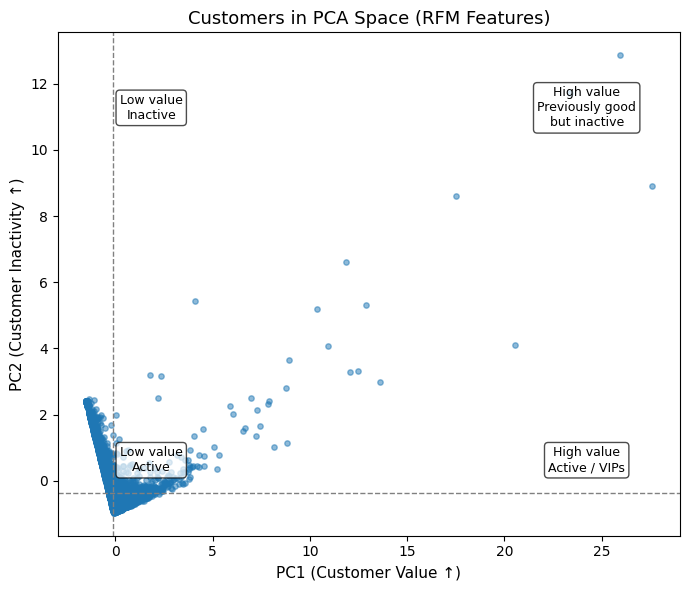

In [ ]:
#Calculate the medians of PC1 and PC2
pc1_median = rfm_pca_df["PC1"].median()
pc2_median = rfm_pca_df["PC2"].median()

#width and height of the plot
fig, ax = plt.subplots(figsize=(7, 6))

#pointsize and transparency
ax.scatter(
    rfm_pca_df["PC1"],
    rfm_pca_df["PC2"],
    s=15,
    c="tab:blue",
    alpha=0.5
)

#axvline() draws a vertical line at PC1 median
#axhline() draws a horizontal line at PC2 median
ax.axvline(pc1_median, color="grey", linestyle="--", linewidth=1)
ax.axhline(pc2_median, color="grey", linestyle="--", linewidth=1)

#axis labels
ax.set_xlabel("PC1 (Customer Value ↑)", fontsize=11)
ax.set_ylabel("PC2 (Customer Inactivity ↑)", fontsize=11)
ax.set_title("Customers in PCA Space (RFM Features)", fontsize=13)

#bottom left
ax.text(0.15, 0.15, "Low value\nActive", transform=ax.transAxes,
        ha="center", va="center", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
#bottom right
ax.text(0.85, 0.15, "High value\nActive / VIPs", transform=ax.transAxes,
        ha="center", va="center", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
#top left
ax.text(0.15, 0.85, "Low value\nInactive", transform=ax.transAxes,
        ha="center", va="center", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
#top right
ax.text(0.85, 0.85, "High value\nPreviously good\nbut inactive", transform=ax.transAxes,
        ha="center", va="center", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.show()


**How GMM learns to cluster data:**

When we fit the Gaussian Mixture Model to our PCA data, the algorithm tries to describe all customers as a combination of several smooth groups. For each cluster, the model learns the **center**, which is the average PC1 and PC2 location of customers in that segment, **the shape**, which tells us how spread out or narrow the group is (how varied customers are), and **the mixing weight**, which is the percentage of all customers that belong to that cluster.



Now that we have each customer as a point in a two dimentional space, we want to group customers with similar behaviour.


In order to find the best number of clusters, So we try from range 1 to 11.
For each number of components we compute the following two metrics:

**The total log-likelihood**: how well the model fits the data

**The BIC (Bayesian Information Criterion)**: penalises models that are too complex.




In [ ]:
components_range = range(1, 11)
log_likelihood_values = []
bic_values = []
gmm_models = []

# we allow each cluster to have its own shape, covariance full
for n_components in components_range:
    model_gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=1
    )
    model_gmm.fit(rfm_pca)
    gmm_models.append(model_gmm)
    total_log_likelihood = model_gmm.score(rfm_pca) * rfm_pca.shape[0]
    log_likelihood_values.append(total_log_likelihood)
    bic_values.append(model_gmm.bic(rfm_pca))


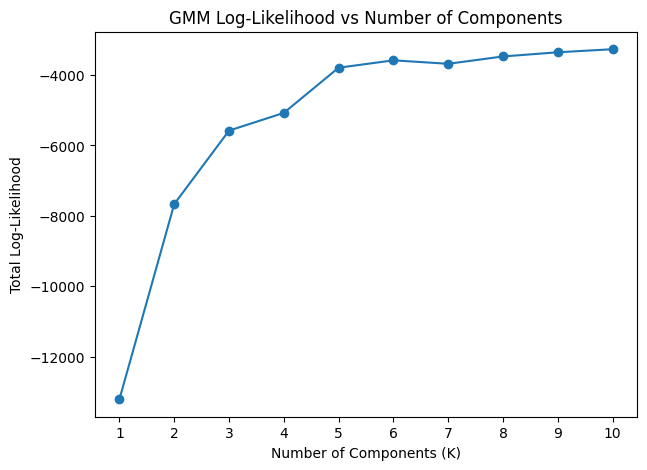

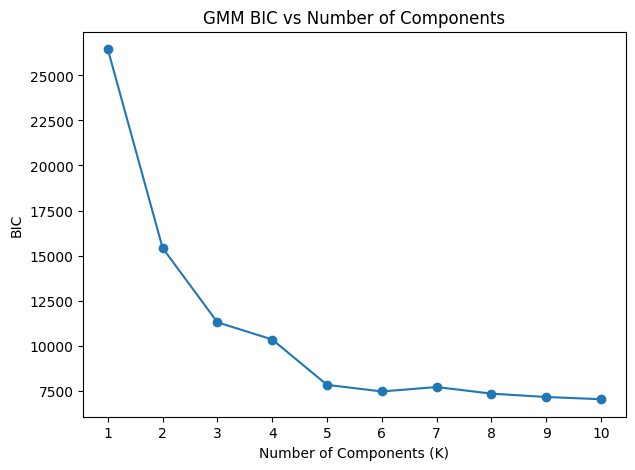

10

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(components_range, log_likelihood_values, marker="o")
plt.xlabel("Number of Components (K)")
plt.ylabel("Total Log-Likelihood")
plt.title("GMM Log-Likelihood vs Number of Components")
plt.xticks(list(components_range))
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(components_range, bic_values, marker="o")
plt.xlabel("Number of Components (K)")
plt.ylabel("BIC")
plt.title("GMM BIC vs Number of Components")
plt.xticks(list(components_range))
plt.show()

best_k_index = int(np.argmin(bic_values))
best_k = components_range[best_k_index]
best_k


**Choosing the best k based on BIC and LogLikelihood Graphs**

We see that the Log-Likelihood rises sharply up to around 5, 6 and 7 clusters, and after that the improvement stops. At the same time, the BIC drops dramatically to k=6. Supposing we do not have many different campaign techniques and would rather keep groups fewer, we choose k=6 as the ideal.

Now we fit the Gaussian Mixture Model with the chosen best k=6 and create a summary table:

We group customers by their GMM cluster label

compute the mean Recency, Frequency, and Monetary value for each cluster

and count how many customers are in each cluster

**Here is what we can interpret from the table**

Cluster 0 represents the largest group of customers who bought recently but do not buy often and spend relatively little.

Cluster 1, spending much, frequently, might be considered VIPs.

Cluster 2 represents very inactive, one time customers who spend little and have not purchased for a long time.

Cluster 3 are elite customers with extremely high spending and very frequent purchases, this group is very small.

Cluster 4 are old, customers who buy rarely and spend little.

Cluster 5 are active, loyal customers who purchased recently, spend a lot, and buy relatively frequently.

In [ ]:
best_k = 6

model_gmm_final = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    random_state=1
)
model_gmm_final.fit(rfm_pca)
#assigns every customer to one cluster-hard assignment
gmm_cluster_labels = model_gmm_final.predict(rfm_pca)
#gives soft probabilities
gmm_cluster_probabilities = model_gmm_final.predict_proba(rfm_pca)

#save cluster labels
rfm_pca_df["Cluster_GMM"] = gmm_cluster_labels
rfm_features["Cluster_GMM"] = gmm_cluster_labels

#store probabilities in a DataFrame
gmm_proba_df = pd.DataFrame(
    gmm_cluster_probabilities,
    index=rfm_features.index,
    columns=[f"Prob_Cluster_{k}" for k in range(best_k)]
)
#compute maximum probability for each customer
rfm_features["GMM_MaxProb"] = gmm_proba_df.max(axis=1)
#Compute the average RFM for each cluster
#Count how many customers are in each cluster
gmm_profile = rfm_features.groupby("Cluster_GMM")[["Recency","Frequency","Monetary"]].mean()
gmm_size = rfm_features["Cluster_GMM"].value_counts().rename("Size")

gmm_summary = pd.concat([gmm_profile, gmm_size], axis=1).sort_index()
gmm_summary


,Recency,Frequency,Monetary,Size
Cluster_GMM,,,,
0,34.550288,3.322229,1174.733102,1561
1,49.592357,17.286624,9247.663758,157
2,162.097003,1.000000,241.201073,1268
3,75.780488,46.853659,62875.423902,41
4,171.731044,2.253219,793.375023,699
5,10.915033,9.588235,3574.284052,612


The model works based on maximum probability when assigning customers to clusters. To **make sure the maximum probabilities are high enough for each customer to justify their assignment**, we **can introduce a threshold, equal to 0.6.** In this case, if the maximum probabilities are above 60%, we can be **rather confident** of customer behaviour in that cluster.

We count certain and uncertain customer IDs. The table shows that out of 4338 unique customers, a decent number of 3871 false for uncertainty, meaning confident results, and 467 not confident customers, which shows roughly 10% uncertainty overall through the model.

These customers might be on the borderlines of some clusters, and their behaviour cannot confidently be defined. (In marketing, there might be the need to analyze them more carefully before designing campaigns for them)



In [ ]:
uncertainty_threshold = 0.6

rfm_features["GMM_Uncertain"] = rfm_features["GMM_MaxProb"] < uncertainty_threshold

rfm_features[["Cluster_GMM", "GMM_MaxProb", "GMM_Uncertain"]].head()


,Cluster_GMM,GMM_MaxProb,GMM_Uncertain
CustomerID,,,
12346.0,3,1.000000,False
12347.0,5,0.982577,False
12348.0,0,0.943846,False
12349.0,0,0.693005,False
12350.0,2,0.977028,False


In [ ]:
transactions["CustomerID"].nunique()


4338

In [ ]:
rfm_features["GMM_Uncertain"].value_counts()


,count
GMM_Uncertain,
False,3871
True,467


Below we can see probabilities for five randomly chosen customers for better understanding. overall, considering a threshold of 60% certainty is enough for our marketing purposes, the model is around 90% confident overall.

In [ ]:
#choose random IDs, don’t select the same ID twice
sample_indices = np.random.choice(rfm_pca.shape[0], size=5, replace=False)
gmm_probabilities_sample = pd.DataFrame(
    gmm_cluster_probabilities[sample_indices],
    index=rfm_pca_df.index[sample_indices],
    columns=[f"Cluster {i}" for i in range(best_k)]
)
gmm_probabilities_sample


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
CustomerID,,,,,,
16565.0,3.446407e-37,1.562654e-11,9.914217e-01,0.000030,0.008548,2.492384e-253
16725.0,6.875647e-19,5.052333e-04,0.000000e+00,0.947836,0.051658,9.350248e-164
16091.0,3.998866e-05,8.830565e-03,2.481559e-17,0.000217,0.990912,1.884175e-41
13739.0,1.555119e-01,1.063374e-04,7.520475e-01,0.000030,0.014777,7.752677e-02
16202.0,2.227197e-36,3.276957e-11,9.830413e-01,0.000046,0.016913,1.621433e-249


In the below code, we loop over each GMM cluster and plot its customers in PC1-PC2 space using a different colour.

In the plot, PC1 represents overall customer value (higher Monetary and Frequency, lower Recency) and PC2 represents customer inactivity (The higher, the more inactive).

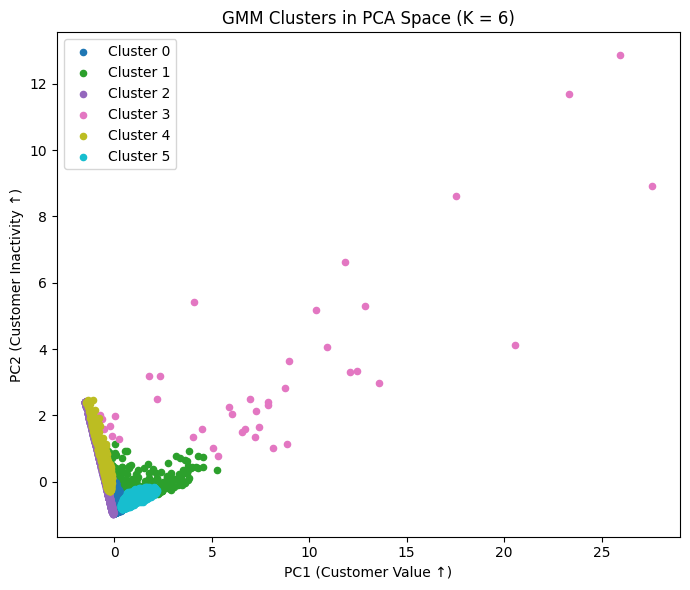

In [ ]:
#up to 10 colours
plt.figure(figsize=(7, 6))
colors = plt.cm.tab10(np.linspace(0, 1, best_k))
#pair each cluster ID with one colour
#dot size 20
for cluster_id, color in zip(range(best_k), colors):
    cluster_mask = rfm_pca_df["Cluster_GMM"] == cluster_id
    plt.scatter(
        rfm_pca_df.loc[cluster_mask, "PC1"],
        rfm_pca_df.loc[cluster_mask, "PC2"],
        s=20,
        c=[color],
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("PC1 (Customer Value ↑)")
plt.ylabel("PC2 (Customer Inactivity ↑)")
plt.title(f"GMM Clusters in PCA Space (K = {best_k})")
plt.legend()
plt.tight_layout()
plt.show()


We see ellipses drawn based on cluster center(mean) and covariance(spread and direction)

 The ellipse around each group shows its general shape and spread. When ellipses are tight and separate, it means those customers have similar behavior and the cluster is clear. When ellipses overlap, it means the groups behave more similarly.

 Most clusters are close together near the bottom-left, showing customers with lower spending or activity, while the pink cluster stretches far out, showing customers with much higher and more varied value.

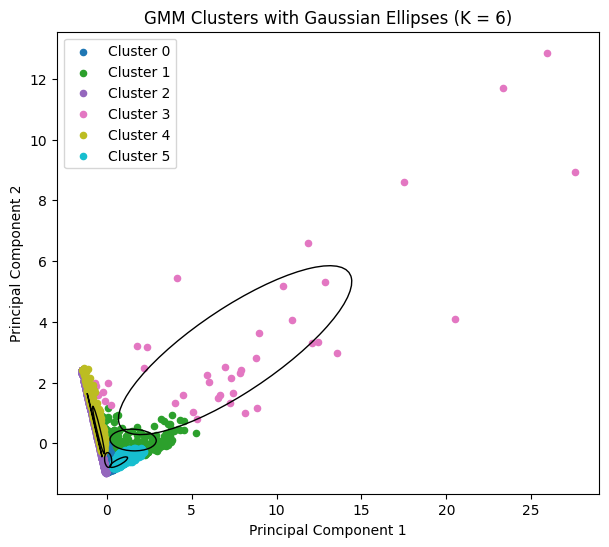

In [ ]:
from matplotlib.patches import Ellipse

def plot_gmm_ellipses(model_gmm, data_2d, labels, ax):
    colors = plt.cm.tab10(np.linspace(0, 1, model_gmm.n_components))

    # Plot scatter points per cluster
    for cluster_id, color in zip(range(model_gmm.n_components), colors):
        cluster_mask = labels == cluster_id
        ax.scatter(
            data_2d[cluster_mask, 0],
            data_2d[cluster_mask, 1],
            s=20,
            c=[color],
            label=f"Cluster {cluster_id}"
        )

    # Plot ellipses
    #Compute ellipse shape for each cluster
    #Centers of ellipses = the cluster means in PCA space
    #Shapes of ellipses = covariance matrices (spread and direction)

    for cluster_id in range(model_gmm.n_components):
        mean = model_gmm.means_[cluster_id]
        cov = model_gmm.covariances_[cluster_id]
    #Convert covariance into ellipse parameters
    #Eigenvalues=lengths of ellipse axes
    #Eigenvectors=orientation (rotation) of ellipse
    #Sorted largest to smallest so the ellipse is correctly oriented
    #After sorting, the largest eigenvalue is always the major axis
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        order = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]
#angle determines how much the ellipse is rotated.
#Width and height are scaled from variance to standard deviation
#eigenvalues are variance, but ellipses need distance (standard deviation)
#Variance measures how spread out the data is, but it is in squared units
#Standard deviation is the square root of variance, which brings it back to normal units
#Multiplying by 2 draws larger amounts of each cluster’s spread

        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * np.sqrt(eigenvalues)

        ellipse = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=angle,
            edgecolor="black",
            facecolor="none",
            linewidth=1
        )
        ax.add_patch(ellipse)

    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(f"GMM Clusters with Gaussian Ellipses (K = {model_gmm.n_components})")
    ax.legend()

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
plot_gmm_ellipses(model_gmm_final, rfm_pca, gmm_cluster_labels, ax)
plt.show()



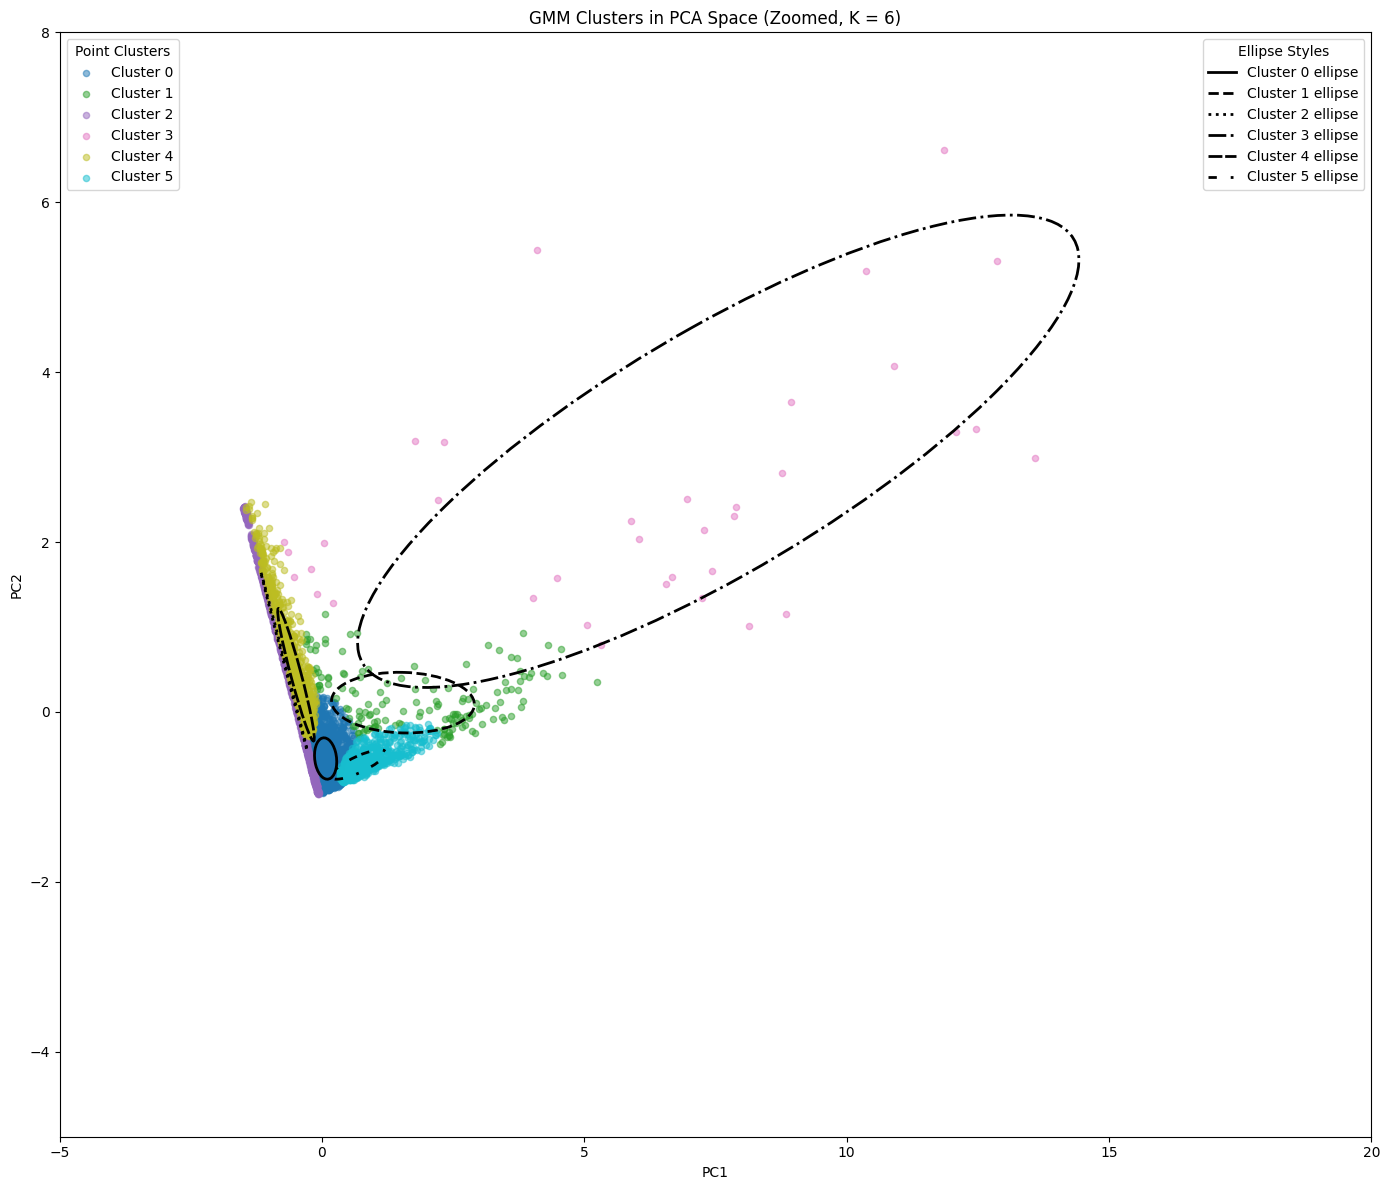

In [ ]:
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

def plot_gmm_ellipses_zoomed_linestyles(model_gmm, data_2d, labels):
    """
    model_gmm      : fitted GaussianMixture model
    data_2d        : 2D numpy array with PCA coordinates (PC1, PC2)
    labels         : hard cluster labels for each point
    """

    fig, ax = plt.subplots(figsize=(14, 12))

    # Colors
    colors = plt.cm.tab10(np.linspace(0, 1, model_gmm.n_components))

    # Different line styles
    linestyles = [
        "solid",
        "dashed",
        "dotted",
        "dashdot",
        (0, (5, 1)),
        (0, (3, 5, 1, 5))
    ]


    for cluster_id, color in zip(range(model_gmm.n_components), colors):
        cluster_mask = labels == cluster_id
        ax.scatter(
            data_2d[cluster_mask, 0],
            data_2d[cluster_mask, 1],
            s=20,
            c=[color],
            alpha=0.5,
            label=f"Cluster {cluster_id}"
        )


    ellipse_handles = []

    for cluster_id in range(model_gmm.n_components):
        mean = model_gmm.means_[cluster_id]
        cov = model_gmm.covariances_[cluster_id]


        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        order = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]

        angle = np.degrees(np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0]
        ))


        width, height = 2 * np.sqrt(eigenvalues)

        ls = linestyles[cluster_id % len(linestyles)]

        ellipse = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=angle,
            edgecolor="black",
            facecolor="none",
            linewidth=2,
            linestyle=ls
        )
        ax.add_patch(ellipse)


        ellipse_handles.append(
            Line2D(
                [0], [0],
                color="black",
                linestyle=ls,
                linewidth=2,
                label=f"Cluster {cluster_id} ellipse"
            )
        )

    point_legend = ax.legend(loc="upper left", title="Point Clusters")
    ax.add_artist(point_legend)


    ax.legend(handles=ellipse_handles, loc="upper right", title="Ellipse Styles")


    ax.set_xlim(-5, 20)
    ax.set_ylim(-5, 8)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"GMM Clusters in PCA Space (Zoomed, K = {model_gmm.n_components})")

    plt.tight_layout()
    plt.show()


plot_gmm_ellipses_zoomed_linestyles(model_gmm_final, rfm_pca, gmm_cluster_labels)


**Interpretation of drawn ellipses**


Cluster 0: Small,customers are very similar.

Cluster 1: Also small, similar members.

Cluster 2: Large and wide, customers vary a lot. Overlaps other clusters, separation is weaker, mixed behaviours inside this cluster.

Cluster 3: Very large and stretched, biggest differences inside the group.
Many points far away, contains outliers.
Far from others, most unique cluster.

Cluster 4: Tall and narrow,similar on one dimension, mixed on the other
Still small, similar members

Cluster 5: Small, similar members.

Below is the overview result of the model, ready to be used by marketing team along with some example tailored business recommendations.

The model is making marketing smarter.

In [ ]:
# Simple business summaries
gmm_summaries = {
    0: "Low-spend but somewhat active buyers",
    1: "High-spend, very frequent loyal customers",
    2: "Very inactive, very low-spend buyers",
    3: "Extremely high-value VIP customers",
    4: "Dormant, low-spend customers",
    5: "Active buyers with mid-level spending"
}

# Short and simple recommended actions
gmm_actions = {
    0: "Use low-cost promotions to increase spending.",
    1: "Reward loyalty with VIP perks.",
    2: "Maybe do not invest.",
    3: "Keep them with exclusive VIP benefits.",
    4: "Use cheap automated reactivation emails.",
    5: "Target with personalised offers to grow value."
}

# Build final table
final_gmm_table = gmm_summary.copy()
final_gmm_table["Segment Name"] = final_gmm_table.index.map(gmm_labels)
final_gmm_table["Summary"] = final_gmm_table.index.map(gmm_summaries)
final_gmm_table["Recommended Action"] = final_gmm_table.index.map(gmm_actions)

final_gmm_table = final_gmm_table[[
    "Segment Name",
    "Recency",
    "Frequency",
    "Monetary",
    "Size",
    "Summary",
    "Recommended Action"
]]

final_gmm_table


,Segment Name,Recency,Frequency,Monetary,Size,Summary,Recommended Action
Cluster_GMM,,,,,,,
0,Low-Spend Occasional Buyers,34.550288,3.322229,1174.733102,1561,Low-spend but somewhat active buyers,Use low-cost promotions to increase spending.
1,High-Spend Frequent Buyers,49.592357,17.286624,9247.663758,157,"High-spend, very frequent loyal customers",Reward loyalty with VIP perks.
2,Long-Inactive Low Buyers,162.097003,1.000000,241.201073,1268,"Very inactive, very low-spend buyers",Maybe do not invest.
3,Elite Super VIPs,75.780488,46.853659,62875.423902,41,Extremely high-value VIP customers,Keep them with exclusive VIP benefits.
4,Dormant Low Buyers,171.731044,2.253219,793.375023,699,"Dormant, low-spend customers",Use cheap automated reactivation emails.
5,Active Mid-Spend Customers,10.915033,9.588235,3574.284052,612,Active buyers with mid-level spending,Target with personalised offers to grow value.


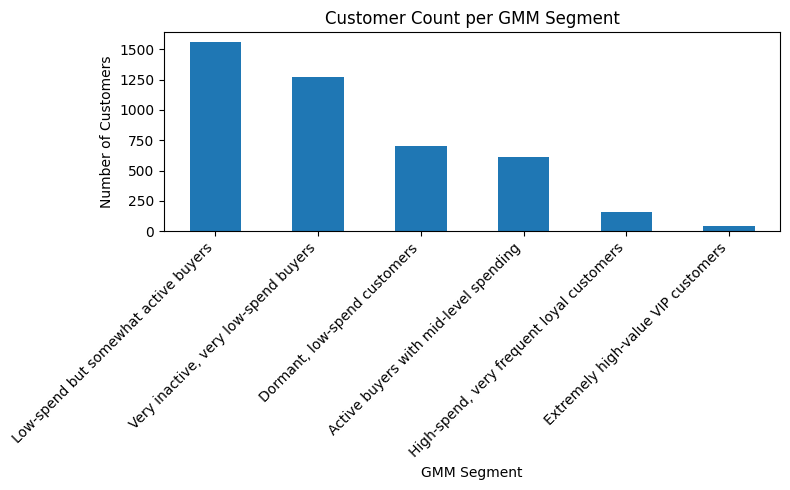

In [ ]:
# --- Create readable segment names for each GMM cluster ---

gmm_summaries = {
    0: "Low-spend but somewhat active buyers",
    1: "High-spend, very frequent loyal customers",
    2: "Very inactive, very low-spend buyers",
    3: "Extremely high-value VIP customers",
    4: "Dormant, low-spend customers",
    5: "Active buyers with mid-level spending"
}

# Add segment names to the RFM table
rfm_features["GMM_Segment"] = rfm_features["Cluster_GMM"].map(gmm_summaries)


# --- Plot counts for each GMM segment ---

plt.figure(figsize=(8, 5))
rfm_features["GMM_Segment"].value_counts().plot(kind="bar")

plt.title("Customer Count per GMM Segment")
plt.xlabel("GMM Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


For even a clearer picture, the count in each cluster is visualized. This might lead businesses to decide on which cluster invest the most.

At last, we add some additional interpretation of **covariance matrices** for clusters below. These explain variation and tilt in each cluster.

In [ ]:
for i, cov in enumerate(model_gmm_final.covariances_):
    print(f"Cluster {i} Covariance Matrix:")
    print(pd.DataFrame(cov))
    print()


Cluster 0 Covariance Matrix:
          0         1
0  0.044852 -0.007794
1 -0.007794  0.059325

Cluster 1 Covariance Matrix:
          0         1
0  1.851999 -0.027441
1 -0.027441  0.127521

Cluster 2 Covariance Matrix:
          0         1
0  0.196376 -0.466396
1 -0.466396  1.108419

Cluster 3 Covariance Matrix:
           0          1
0  47.257735  15.507132
1  15.507132   7.729857

Cluster 4 Covariance Matrix:
          0         1
0  0.121719 -0.259984
1 -0.259984  0.608459

Cluster 5 Covariance Matrix:
          0         1
0  0.272278  0.072433
1  0.072433  0.029998



**Each cluster's covariance interpretation**

Cluster 0
Variances (0.044, 0.059) are extremely small, very tight, compact cluster.
Covariance (–0.007) is almost zero, no meaningful tilt.

Cluster 1
Variances (1.85, 0.12) show long stretch along PC1 but tight along PC2.
Covariance (–0.027) is small, slight downward tilt.

Cluster 2
Variances (0.19, 1.10), moderate spread, mainly along PC2.
Covariance (–0.466), clear downward tilt.

Cluster 3
Variances (47.26, 7.73), very wide, extremely spread out cluster.
Covariance (15.50), strong upward diagonal tilt.

Cluster 4
Variances (0.12, 0.61), fairly compact with moderate height.
Covariance (–0.259), mild downward tilt.

Cluster 5
Variances (0.27, 0.02), tight cluster, slightly stretched along PC1.
Covariance (0.072), very slight upward tilt.